### Importing Libraries

In [2]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import yfinance as yf

### Cleaning Data

In [4]:
df=yf.download('^NSEI',start='2015-01-01',end='2026-07-31')

[*********************100%***********************]  1 of 1 completed


In [5]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800
2015-01-09,8284.500000,8303.299805,8190.799805,8285.450195,148000
2015-01-12,8323.000000,8332.599609,8245.599609,8291.349609,103200
2015-01-13,8299.400391,8356.650391,8267.900391,8346.150391,129600


In [6]:
df.isnull().sum()

Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Open    ^NSEI     0
Volume  ^NSEI     0
dtype: int64

In [7]:
df[df.duplicated()]

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,


In [8]:
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df = df.reset_index()

In [9]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
1,2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2,2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
3,2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
4,2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [10]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [11]:
df['Return']=df['Close'].pct_change()

In [12]:
df.head()

,Date,Close,High,Low,Open,Volume,Return
0,2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN
1,2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031
2,2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964
3,2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107
4,2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354


#  1. Buy and Hold Strategy

In [13]:
df['Cummulative_Return']=(1+df['Return']).cumprod()

In [14]:
df.head()

,Date,Close,High,Low,Open,Volume,Return,Cummulative_Return
0,2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN
1,2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031,0.997969
2,2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964,0.968066
3,2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107,0.965058
4,2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354,0.980841


In [15]:
investment=100000

In [16]:
df['Portfolio_Value']=investment*df['Cummulative_Return']

In [17]:
px.line(df,
        x='Date',y='Close',
       height=500,
       title='Nifty-50 over time')

px.line(df,
        x='Date',y='Portfolio_Value',
       height=500,
       title='1 Lakh Invested in Nifty-50')

#### Return

In [140]:
buy_and_hold_return=(Buy_and_hold_end_value-Buy_and_hold_start_value)/Buy_and_hold_start_value

In [141]:
print(f'CAGR OF NIFTY-50 FROM 2015 : {buy_and_hold_return:.2%}')

CAGR OF NIFTY-50 FROM 2015 : 189.65%


### CAGR

In [157]:
Buy_and_hold_start_value=df['Portfolio_Value'].iloc[1]
Buy_and_hold_end_value=df['Portfolio_Value'].iloc[-1]

In [158]:
total_years=(df['Date'].iloc[-1]-df['Date'].iloc[0]).days/365.25

In [159]:
Buy_hold_CAGR=(Buy_and_hold_end_value/Buy_and_hold_start_value)**(1/total_years)-1

In [160]:
print(f'CAGR OF NIFTY-50 FROM 2015 : {Buy_hold_CAGR:.2%}')

CAGR OF NIFTY-50 FROM 2015 : 9.64%


### Drawdown

In [23]:
df['Peak']=df['Portfolio_Value'].cummax()

In [24]:
df.head()

,Date,Close,High,Low,Open,Volume,Return,Cummulative_Return,Portfolio_Value,Peak
0,2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN,NaN,NaN
1,2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031,0.997969,99796.916136,99796.916136
2,2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964,0.968066,96806.602488,99796.916136
3,2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107,0.965058,96505.844346,99796.916136
4,2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354,0.980841,98084.074324,99796.916136


In [25]:
df['Drawdown']=df['Peak']-df['Portfolio_Value']

In [26]:
df.head()

,Date,Close,High,Low,Open,Volume,Return,Cummulative_Return,Portfolio_Value,Peak,Drawdown
0,2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031,0.997969,99796.916136,99796.916136,0.000000
2,2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964,0.968066,96806.602488,99796.916136,2990.313648
3,2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107,0.965058,96505.844346,99796.916136,3291.071789
4,2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354,0.980841,98084.074324,99796.916136,1712.841812


In [27]:
df['Drawdown%']=df['Drawdown']/df['Peak']

In [28]:
Max_Drawdown=df['Drawdown%'].max()

In [29]:
print(f'Maximum Drawback Till Date in Nifty-50 : {Max_Drawdown:.2%}')

Maximum Drawback Till Date in Nifty-50 : 38.44%


# MA-20 Stratergy

In [30]:
df['MA20']=df['Close'].rolling(20).mean()

In [31]:
df.tail()

,Date,Close,High,Low,Open,Volume,Return,Cummulative_Return,Portfolio_Value,Peak,Drawdown,Drawdown%,MA20
2844,2026-07-24,23767.449219,23823.599609,23606.300781,23666.349609,333900,-0.004280,2.830992,283099.162830,313604.990426,30505.827596,0.097275,24097.664941
2845,2026-07-27,23995.949219,24011.599609,23891.550781,23928.400391,319400,0.009614,2.858209,285820.875123,313604.990426,27784.115303,0.088596,24100.149902
2846,2026-07-28,23985.349609,24041.150391,23954.599609,23971.250000,437800,-0.000442,2.856946,285694.620912,313604.990426,27910.369514,0.088998,24106.129883
2847,2026-07-29,24250.199219,24283.550781,24136.750000,24176.650391,424200,0.011042,2.888493,288849.301164,313604.990426,24755.689262,0.078939,24118.347363
2848,2026-07-30,24317.150391,24342.949219,24187.099609,24249.550781,400600,0.002761,2.896468,289646.770869,313604.990426,23958.219557,0.076396,24125.419922


In [32]:
px.line(df,
        x='Date',y=['Close','MA20'],
        height=500,
        title='MA20 Buy Sell')

In [33]:
ma20_df = df[["Date", "Close", "High", "Low", "Open", "Volume"]].copy()

In [34]:
ma20_df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
1,2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2,2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
3,2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
4,2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [35]:
ma20_df['MA20']=ma20_df['Close'].rolling(20).mean()

In [36]:
ma20_df['Buy']=((ma20_df['MA20']<ma20_df['Close']) & (ma20_df['MA20'].shift(1)>=ma20_df['Close'].shift(1)))

In [37]:
ma20_df.tail()

,Date,Close,High,Low,Open,Volume,MA20,Buy
2844,2026-07-24,23767.449219,23823.599609,23606.300781,23666.349609,333900,24097.664941,False
2845,2026-07-27,23995.949219,24011.599609,23891.550781,23928.400391,319400,24100.149902,False
2846,2026-07-28,23985.349609,24041.150391,23954.599609,23971.250000,437800,24106.129883,False
2847,2026-07-29,24250.199219,24283.550781,24136.750000,24176.650391,424200,24118.347363,True
2848,2026-07-30,24317.150391,24342.949219,24187.099609,24249.550781,400600,24125.419922,False


In [38]:
ma20_df["Sell"] = (
    (ma20_df["Close"] < ma20_df["MA20"]) &
    (ma20_df["Close"].shift(1) >= ma20_df["MA20"].shift(1))
)

In [39]:
ma20_df[ma20_df["Buy"] | ma20_df["Sell"]][
    ["Date", "Close", "MA20", "Buy", "Sell"]
]

,Date,Close,MA20,Buy,Sell
25,2015-02-09,8526.349609,8662.175000,False,True
29,2015-02-13,8805.500000,8727.969971,True,False
34,2015-02-23,8754.950195,8773.534912,False,True
36,2015-02-25,8767.250000,8762.697412,True,False
37,2015-02-26,8683.849609,8751.174902,False,True
...,...,...,...,...,...
2834,2026-07-10,24206.900391,24044.129980,True,False
2836,2026-07-14,24052.050781,24083.442480,False,True
2839,2026-07-17,24334.300781,24095.577539,True,False
2842,2026-07-22,23996.250000,24119.695020,False,True


In [40]:
ma20_df["Cash"] = 0.0
ma20_df["Units"] = 0.0
ma20_df["Portfolio_Value"] = 0.0

In [41]:
cash = 100000
units = 0

In [42]:
for i in range(len(ma20_df)):
    price=ma20_df.loc[i,'Close']

    if ma20_df.loc[i,"Buy"] and units==0:
        units=cash/price
        cash=0
    elif ma20_df.loc[i,"Sell"] and units>0:
        cash=units*price
        units=0
    ma20_df.loc[i, "cash"] = cash
    ma20_df.loc[i, "Units"] = units
    ma20_df.loc[i, "Portfolio_Value"] = cash + (units * price)

In [43]:
px.line(ma20_df,
        x='Date',y='Portfolio_Value',
        title='1Lakh Invested in MA 20 Strategy',
        height=500)

#### CAGR,MAX DRAWDOWN,RETURN

In [44]:
ma20_start_value=100000
ma20_end_value=ma20_df['Portfolio_Value'].iloc[-1]
MA20_CAGR =(ma20_end_value/ma20_start_value)**(1/total_years)-1

In [45]:
ma20_df['Peak']=ma20_df['Portfolio_Value'].cummax()
ma20_df['Drawdown']=ma20_df['Peak']-ma20_df['Portfolio_Value']
ma20_df['Drawdown%']=ma20_df['Drawdown']/ma20_df['Peak']
MA20_MaxDrawdown=ma20_df['Drawdown%'].max()


In [46]:
MA20_Return=(ma20_df['Portfolio_Value'].iloc[-1] - ma20_df['Portfolio_Value'].iloc[0])/ma20_df['Portfolio_Value'].iloc[0]

In [47]:
ma20_df.tail()

,Date,Close,High,Low,Open,Volume,MA20,Buy,Sell,Cash,Units,Portfolio_Value,cash,Peak,Drawdown,Drawdown%
2844,2026-07-24,23767.449219,23823.599609,23606.300781,23666.349609,333900,24097.664941,False,False,0.0,0.000000,229770.439383,229770.439383,253377.124792,23606.685409,0.093168
2845,2026-07-27,23995.949219,24011.599609,23891.550781,23928.400391,319400,24100.149902,False,False,0.0,0.000000,229770.439383,229770.439383,253377.124792,23606.685409,0.093168
2846,2026-07-28,23985.349609,24041.150391,23954.599609,23971.250000,437800,24106.129883,False,False,0.0,0.000000,229770.439383,229770.439383,253377.124792,23606.685409,0.093168
2847,2026-07-29,24250.199219,24283.550781,24136.750000,24176.650391,424200,24118.347363,True,False,0.0,9.474992,229770.439383,0.000000,253377.124792,23606.685409,0.093168
2848,2026-07-30,24317.150391,24342.949219,24187.099609,24249.550781,400600,24125.419922,False,False,0.0,9.474992,230404.801189,0.000000,253377.124792,22972.323603,0.090665


In [48]:
print(f'MA20 Return : {MA20_Return:.2%}')
print(f'MA20 CAGR : {MA20_CAGR:.2%}')
print(f'MA20 Drawdown : {MA20_MaxDrawdown:.2%}')

MA20 Return : 130.40%
MA20 CAGR : 7.48%
MA20 Drawdown : 16.19%


# 3. MA 50 Strategy

In [49]:
ma50_df = df[["Date", "Close"]].copy()

In [50]:
ma50_df['MA50']=ma50_df['Close'].rolling(50).mean()

In [51]:
ma50_df.tail()

,Date,Close,MA50
2844,2026-07-24,23767.449219,23850.433906
2845,2026-07-27,23995.949219,23856.560898
2846,2026-07-28,23985.349609,23863.397891
2847,2026-07-29,24250.199219,23875.402891
2848,2026-07-30,24317.150391,23889.385898


In [52]:
px.line(ma50_df,
        x='Date',y=['Close','MA50'],
        height=500,
        title='MA50 Buy Sell' )

In [53]:
ma50_df['Buy']=((ma50_df['Close']>ma50_df['MA50']) & (ma50_df['Close'].shift(1)<=ma50_df['MA50'].shift(1)))

In [54]:
ma50_df['Sell']=((ma50_df['Close']<ma50_df['MA50']) & (ma50_df['Close'].shift(1)<=ma50_df['MA50'].shift(1)))

In [55]:
ma50_df[ma50_df["Buy"] | ma50_df["Sell"]]

,Date,Close,MA50,Buy,Sell
52,2015-03-20,8570.900391,8688.971982,False,True
53,2015-03-23,8550.900391,8697.947988,False,True
54,2015-03-24,8542.950195,8704.115000,False,True
55,2015-03-25,8530.799805,8709.040996,False,True
56,2015-03-26,8342.150391,8709.424004,False,True
...,...,...,...,...,...
2814,2026-06-11,23161.599609,23703.233945,False,True
2815,2026-06-12,23622.900391,23719.299961,False,True
2816,2026-06-15,23853.900391,23749.749961,True,False
2823,2026-06-24,24021.650391,23847.692969,True,False


In [56]:
ma50_df["Cash"] = 0.0
ma50_df["Units"] = 0.0
ma50_df["Portfolio_Value"] = 0.0

In [57]:
cash=100000
units=0

In [58]:
for i in range(len(ma50_df)):
    price=ma50_df.loc[i,'Close']

    if ma50_df.loc[i,"Buy"] and units==0:
        units=cash/price
        cash=0
    elif ma50_df.loc[i,"Sell"] and units>0:
        cash=units*price
        units=0
    ma50_df.loc[i, "cash"] = cash
    ma50_df.loc[i, "Units"] = units
    ma50_df.loc[i, "Portfolio_Value"] = cash + (units * price)

In [59]:
ma50_df.tail()

,Date,Close,MA50,Buy,Sell,Cash,Units,Portfolio_Value,cash
2844,2026-07-24,23767.449219,23850.433906,False,False,0.0,9.907129,235467.193014,0.0
2845,2026-07-27,23995.949219,23856.560898,True,False,0.0,9.907129,237730.972064,0.0
2846,2026-07-28,23985.349609,23863.397891,False,False,0.0,9.907129,237625.960363,0.0
2847,2026-07-29,24250.199219,23875.402891,False,False,0.0,9.907129,240249.859693,0.0
2848,2026-07-30,24317.150391,23889.385898,False,False,0.0,9.907129,240913.153611,0.0


In [60]:
px.line(ma50_df,
        x='Date',y='Portfolio_Value',
        height=500,
        title = '1 Lakh Invested in MA 50 Startegy')

#### CAGR,DRAWDOWN,RETRUN

In [61]:
ma50_start_value=100000
ma50_end_value=ma50_df['Portfolio_Value'].iloc[-1]
MA50_CAGR=(ma50_end_value/ma50_start_value)**(1/total_years)-1

In [62]:
ma50_df['Peak']=ma50_df['Portfolio_Value'].cummax()
ma50_df['Drawdown']=ma50_df['Peak']-ma50_df['Portfolio_Value']
ma50_df['Drawdown%']=ma50_df['Drawdown']/ma50_df['Peak']
MA50_MaxDrawdown=ma50_df['Drawdown%'].max()

In [63]:
MA50_Return=(ma50_df['Portfolio_Value'].iloc[-1]-ma50_df['Portfolio_Value'].iloc[0])/ma50_df['Portfolio_Value'].iloc[0]

In [64]:
print(f'MA50 Return : {MA50_Return:.2%}')
print(f'MA50 CAGR : {MA50_CAGR:.2%}')
print(f'MA50 Drawdown : {MA50_MaxDrawdown:.2%}')

MA50 Return : 140.91%
MA50 CAGR : 7.89%
MA50 Drawdown : 16.29%


# RSI Startegy

In [65]:
rsi_df=df[['Date','Close']].copy()

In [66]:
rsi_df.head()

,Date,Close
0,2015-01-02,8395.450195
1,2015-01-05,8378.400391
2,2015-01-06,8127.350098
3,2015-01-07,8102.100098
4,2015-01-08,8234.599609


In [67]:
rsi_df['Change']=rsi_df['Close'].diff()

In [68]:
rsi_df.head()

,Date,Close,Change
0,2015-01-02,8395.450195,NaN
1,2015-01-05,8378.400391,-17.049805
2,2015-01-06,8127.350098,-251.050293
3,2015-01-07,8102.100098,-25.250000
4,2015-01-08,8234.599609,132.499512


In [69]:
rsi_df['Gain']=rsi_df['Change'].clip(lower=0)
rsi_df['Lose']=-rsi_df['Change'].clip(upper=0)

In [70]:
rsi_df['Avg_Gain']=rsi_df['Gain'].rolling(14).mean()
rsi_df['Avg_Loss']=rsi_df['Lose'].rolling(14).mean()

In [71]:
rsi_df["RS"] = rsi_df["Avg_Gain"] / rsi_df["Avg_Loss"]

In [72]:
rsi_df['RSI']=100-(100/(1+rsi_df['RS']))

In [73]:
rsi_df.tail()

,Date,Close,Change,Gain,Lose,Avg_Gain,Avg_Loss,RS,RSI
2844,2026-07-24,23767.449219,-102.150391,0.000000,102.150391,44.067801,91.417829,0.482048,32.525812
2845,2026-07-27,23995.949219,228.500000,228.500000,-0.000000,60.389230,89.157087,0.677335,40.381623
2846,2026-07-28,23985.349609,-10.599609,0.000000,10.599609,60.389230,53.010742,1.139189,53.253302
2847,2026-07-29,24250.199219,264.849609,264.849609,-0.000000,73.539202,53.010742,1.387251,58.110813
2848,2026-07-30,24317.150391,66.951172,66.951172,-0.000000,60.885742,53.010742,1.148555,53.457087


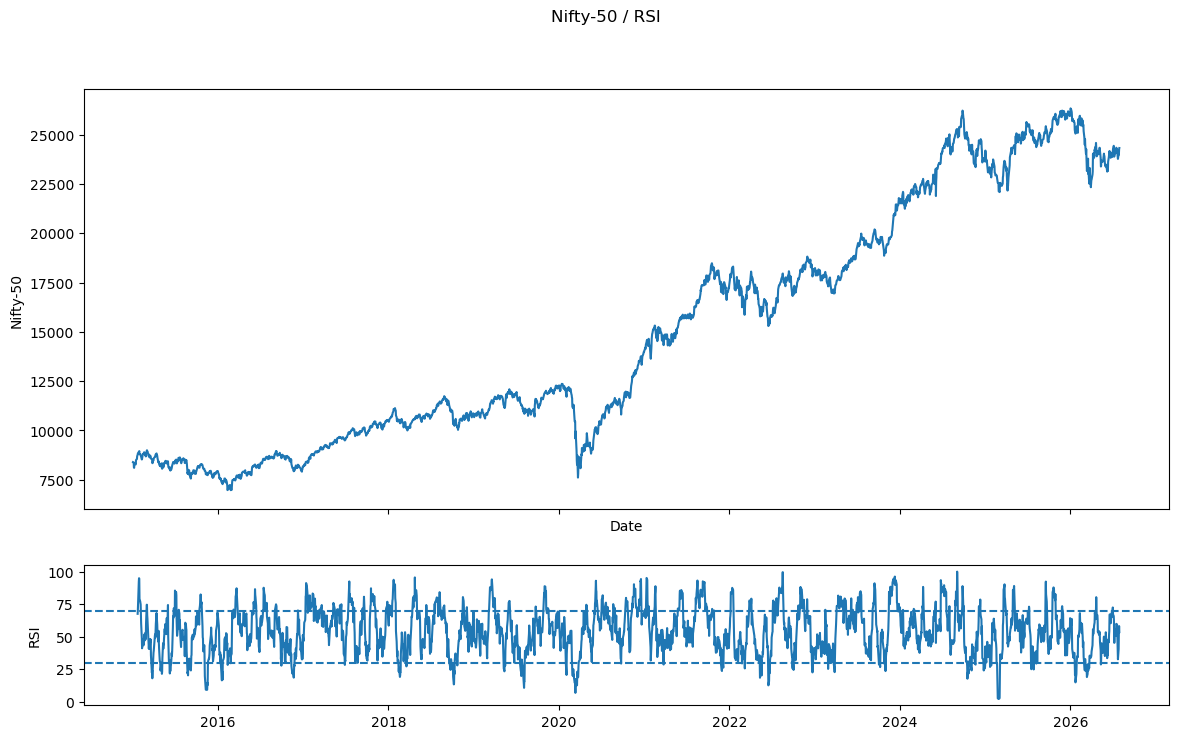

In [74]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)
ax1.plot(rsi_df['Date'],rsi_df['Close'],label='Nifty-50')
ax1.set_xlabel('Date')
ax1.set_ylabel('Nifty-50')

ax2.plot(rsi_df['Date'],rsi_df['RSI'],label='RSI')
ax2.axhline(70, linestyle="--")
ax2.axhline(30, linestyle="--")
ax2.set_ylabel('RSI')
fig.suptitle('Nifty-50 / RSI ')

plt.show()

## Buy/Sell By RSI

In [75]:
rsi_df['Buy']=((rsi_df['RSI']>30) & (rsi_df['RSI'].shift(1)<=30))
rsi_df['Sell']=((rsi_df['RSI']>70) & (rsi_df['RSI'].shift(1)<=70))               

In [76]:
rsi_df[rsi_df['Buy'] | rsi_df['Sell']]

,Date,Close,Change,Gain,Lose,Avg_Gain,Avg_Loss,RS,RSI,Buy,Sell
15,2015-01-23,8835.599609,74.199219,74.199219,-0.00,55.639265,22.982178,2.420974,70.768563,False,True
39,2015-03-02,8956.750000,112.150391,112.150391,-0.00,46.725028,15.982143,2.923577,74.513054,False,True
58,2015-03-30,8492.299805,150.899414,150.899414,-0.00,22.649902,38.346331,0.590667,37.133280,True,False
82,2015-05-08,8191.500000,134.200195,134.200195,-0.00,29.171456,58.778599,0.496294,33.168207,True,False
98,2015-06-01,8433.400391,-0.250000,0.000000,0.25,33.439314,11.550014,2.895175,74.327214,False,True
...,...,...,...,...,...,...,...,...,...,...,...
2750,2026-03-05,24765.900391,285.400391,285.400391,-0.00,68.871512,143.250000,0.480778,32.467953,True,False
2763,2026-03-24,22912.400391,399.750000,399.750000,-0.00,118.410714,230.417829,0.513896,33.945248,True,False
2779,2026-04-21,24576.599609,211.750000,211.750000,-0.00,193.567801,68.067801,2.843750,73.983739,False,True
2794,2026-05-13,23412.599609,33.048828,33.048828,-0.00,59.260603,128.224888,0.462161,31.608101,True,False


In [77]:
cash = 100000
units = 0

rsi_df["Cash"] = 0.0
rsi_df["Units"] = 0.0
rsi_df["Portfolio_Value"] = 0.0

for i in range(len(rsi_df)):
    price=rsi_df.loc[i,'Close']

    if rsi_df.loc[i,'Buy'] and units==0:
        units=cash/price
        cash=0

    elif rsi_df.loc[i,'Sell'] and units>0:
        cash=units*price
        units=0

    rsi_df.loc[i,'Cash']= cash
    rsi_df.loc[i,'Units']=units
    rsi_df.loc[i,'Portfolio_Value']=cash + (units*price)

In [78]:
rsi_df.tail()

,Date,Close,Change,Gain,Lose,Avg_Gain,Avg_Loss,RS,RSI,Buy,Sell,Cash,Units,Portfolio_Value
2844,2026-07-24,23767.449219,-102.150391,0.000000,102.150391,44.067801,91.417829,0.482048,32.525812,False,False,94208.449881,0.0,94208.449881
2845,2026-07-27,23995.949219,228.500000,228.500000,-0.000000,60.389230,89.157087,0.677335,40.381623,False,False,94208.449881,0.0,94208.449881
2846,2026-07-28,23985.349609,-10.599609,0.000000,10.599609,60.389230,53.010742,1.139189,53.253302,False,False,94208.449881,0.0,94208.449881
2847,2026-07-29,24250.199219,264.849609,264.849609,-0.000000,73.539202,53.010742,1.387251,58.110813,False,False,94208.449881,0.0,94208.449881
2848,2026-07-30,24317.150391,66.951172,66.951172,-0.000000,60.885742,53.010742,1.148555,53.457087,False,False,94208.449881,0.0,94208.449881


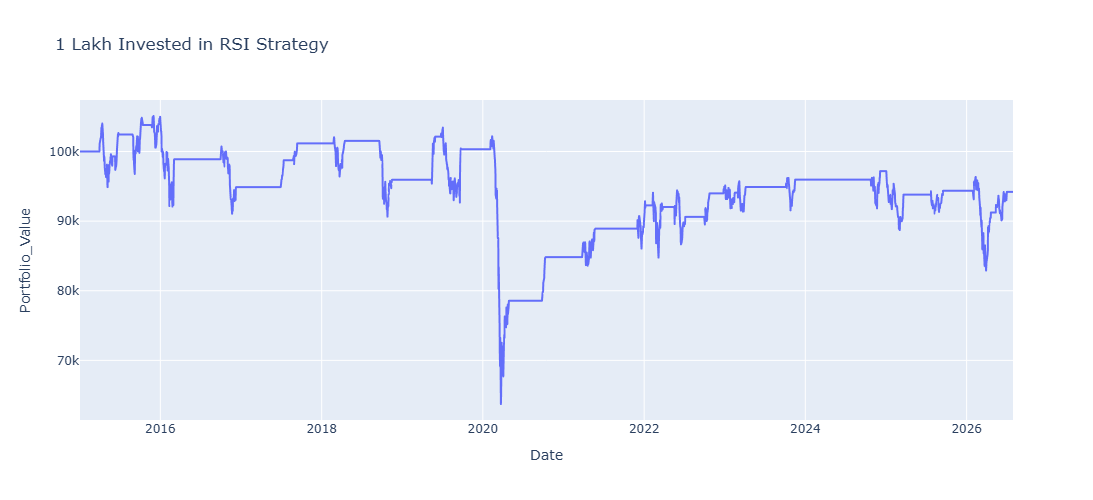

In [79]:
px.line(rsi_df,
        x='Date',y='Portfolio_Value',
        height=500,
        title='1 Lakh Invested in RSI Strategy')

#### CAGR,MAX DRAWDOWN,TOTAL RETURN

In [80]:
rsi_start_value= 100000
rsi_end_value=rsi_df['Portfolio_Value'].iloc[-1]
RSI_CAGR=(rsi_end_value/rsi_start_value)**(1/total_years)-1


In [81]:
RSI_TOTAL_RETURN=(rsi_end_value-rsi_start_value)/rsi_start_value

In [82]:
rsi_df['Peak']=rsi_df['Portfolio_Value'].cummax()
rsi_df['Drawdown']=rsi_df['Peak']-rsi_df['Portfolio_Value']
rsi_df['Drawdown%']=rsi_df['Drawdown']/rsi_df['Peak']
RSI_MAX_DRAWDOWN=rsi_df['Drawdown%'].max()

In [83]:
print(f'CAGR of RSI Strategy : {RSI_CAGR:.2%}')
print(f'TOTAL RETURN of RSI Strategy : {RSI_TOTAL_RETURN:.2%}')
print(f'MAX DRAWDOWN of RSI Strategy : {RSI_MAX_DRAWDOWN:.2%}')

CAGR of RSI Strategy : -0.51%
TOTAL RETURN of RSI Strategy : -5.79%
MAX DRAWDOWN of RSI Strategy : 39.36%


# SIP Investing

In [84]:
sip_df=df[['Close','Date']].copy()

In [85]:
sip_df.head()

,Close,Date
0,8395.450195,2015-01-02
1,8378.400391,2015-01-05
2,8127.350098,2015-01-06
3,8102.100098,2015-01-07
4,8234.599609,2015-01-08


In [88]:
sip_df['Month']=sip_df['Date'].dt.to_period("M")

In [89]:
sip_df.head()

,Close,Date,Month
0,8395.450195,2015-01-02,2015-01
1,8378.400391,2015-01-05,2015-01
2,8127.350098,2015-01-06,2015-01
3,8102.100098,2015-01-07,2015-01
4,8234.599609,2015-01-08,2015-01


#### Taking 1 day of month only

In [90]:
sip_df=sip_df.groupby('Month').first().reset_index()

In [91]:
sip_df.head()

,Month,Close,Date
0,2015-01,8395.450195,2015-01-02
1,2015-02,8797.400391,2015-02-02
2,2015-03,8956.750000,2015-03-02
3,2015-04,8586.250000,2015-04-01
4,2015-05,8331.950195,2015-05-04


In [95]:
sip_amount=5000
sip_df['Sip_Amount']=5000
sip_df['Units_Bought']=sip_amount/sip_df['Close']

In [96]:
sip_df['Cummulative_Units']=sip_df['Units_Bought'].cumsum()

In [98]:
sip_df['Total_Invested']=sip_df['Sip_Amount'].cumsum()

In [99]:
sip_df.tail()

,Month,Close,Date,Units_Bought,Cummulative_Units,Sip_Amount,Total_Invested
134,2026-03,24865.699219,2026-03-02,0.201080,53.460982,5000,675000
135,2026-04,22679.400391,2026-04-01,0.220464,53.681446,5000,680000
136,2026-05,24119.300781,2026-05-04,0.207303,53.888749,5000,685000
137,2026-06,23382.599609,2026-06-01,0.213834,54.102583,5000,690000
138,2026-07,24005.849609,2026-07-01,0.208283,54.310866,5000,695000


In [100]:
sip_df['Portfolio_Value']=sip_df['Cummulative_Units']*sip_df['Close']

In [106]:
pd.set_option('display.float_format','{:,.0f}'.format)

In [107]:
sip_df.tail()

,Month,Close,Date,Units_Bought,Cummulative_Units,Sip_Amount,Total_Invested,Portfolio_Value
134,2026-03,"24,866",2026-03-02,0,53,5000,675000,"1,329,345"
135,2026-04,"22,679",2026-04-01,0,54,5000,680000,"1,217,463"
136,2026-05,"24,119",2026-05-04,0,54,5000,685000,"1,299,759"
137,2026-06,"23,383",2026-06-01,0,54,5000,690000,"1,265,059"
138,2026-07,"24,006",2026-07-01,0,54,5000,695000,"1,303,778"


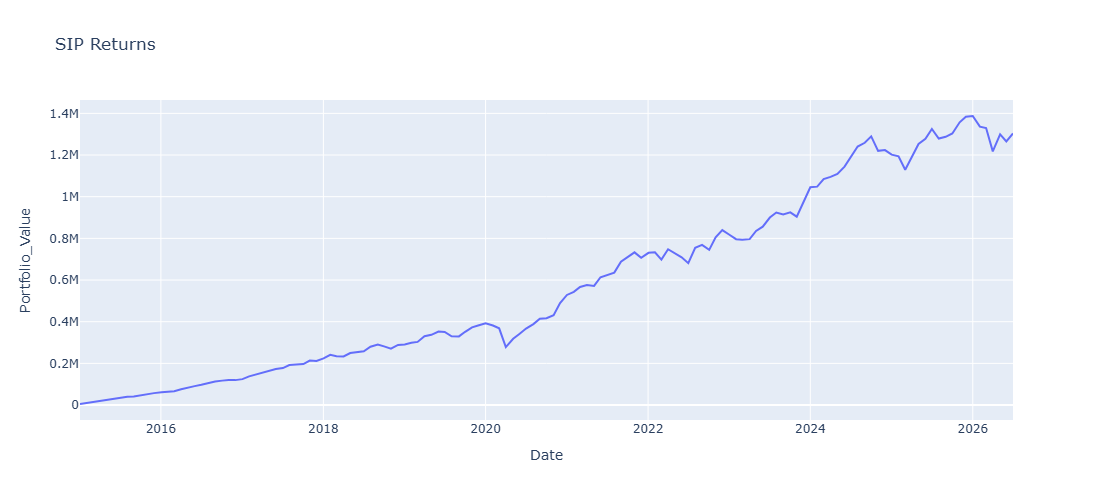

In [110]:
px.line(sip_df,
        x='Date',y='Portfolio_Value',
        height=500,
        title='SIP Returns')

### XIRR,MAX DRAWDOWN,TOTAL RETURN in SIP MODE

In [112]:
sip_df['Peak']=sip_df['Portfolio_Value'].cummax()
sip_df['Drawdown']=sip_df['Peak']-sip_df['Portfolio_Value']
sip_df['Drawdown%']=sip_df['Drawdown']/sip_df['Peak']
SIP_MAX_DRAWDOWN=sip_df['Drawdown%'].max()

In [113]:
SIP_TOTAL_RETURN=(sip_df['Portfolio_Value'].iloc[-1]-sip_df['Total_Invested'].iloc[-1])/sip_df['Total_Invested'].iloc[-1]

In [114]:
from scipy.optimize import brentq
import numpy as np



In [118]:
cash_flows=[-x for x in sip_df['Sip_Amount']]
cash_flows[-1] += sip_df['Portfolio_Value'].iloc[-1]
dates=sip_df['Date']

def xnpv(rate,cash_flows,dates):
    start_date=sip_df['Date'].iloc[0]
    return sum(
        cf / (1 + rate) ** ((date - start_date).days / 365.25)
        for cf, date in zip(cash_flows, dates)
    )
XIRR=brentq(lambda rate : xnpv(rate,cash_flows,dates),
            -0.9999,
            10)


In [129]:
print(f' MAX DAWDOWN IN SIP MODE : {SIP_MAX_DRAWDOWN:.2%}')
print(f' TOTAL RETURN IN SIP MODE : {SIP_TOTAL_RETURN:.2%}')
print(f' XIRR IN SIP MODE : {XIRR:.2%}')

 MAX DAWDOWN IN SIP MODE : 29.13%
 TOTAL RETURN IN SIP MODE : 87.59%
 XIRR IN SIP MODE : 10.50%


# Comparision of Strategies

In [139]:
sip_end_value=sip_df['Portfolio_Value'].iloc[-1]

In [176]:
comparison_df=pd.DataFrame({
    "Strategy":['Buy and Hold','MA-20','MA-50','RSI','SIP'],
    'Final_Value':[Buy_and_hold_end_value,ma20_end_value,ma50_end_value,rsi_end_value,sip_end_value],
    'Return':[buy_and_hold_return,MA20_Return,MA50_Return,RSI_TOTAL_RETURN,SIP_TOTAL_RETURN],
     "Max Drawdown": [
        Max_Drawdown,MA20_MaxDrawdown,MA50_MaxDrawdown,RSI_MAX_DRAWDOWN,SIP_MAX_DRAWDOWN
    ],
    "CAGR/XIRR":[Buy_hold_CAGR,MA20_CAGR,MA50_CAGR,RSI_CAGR,XIRR]
}).reset_index()
    

In [177]:
comparison_df

,index,Strategy,Final_Value,Return,Max Drawdown,CAGR/XIRR
0,0,Buy and Hold,"289,647",2,0,0
1,1,MA-20,"230,405",1,0,0
2,2,MA-50,"240,913",1,0,0
3,3,RSI,"94,208",-0,0,-0
4,4,SIP,"1,303,778",1,0,0


In [180]:
comparison_df.style.format({
    "Return": "{:.2%}",
    "Max Drawdown": "{:.2%}",
    "Final_Value":"{:.0f}",
    "CAGR/XIRR": "{:.2%}"
})

,index,Strategy,Final_Value,Return,Max Drawdown,CAGR/XIRR
0,0,Buy and Hold,289647,189.65%,38.44%,9.64%
1,1,MA-20,230405,130.40%,16.19%,7.48%
2,2,MA-50,240913,140.91%,16.29%,7.89%
3,3,RSI,94208,-5.79%,39.36%,-0.51%
4,4,SIP,1303778,87.59%,29.13%,10.50%


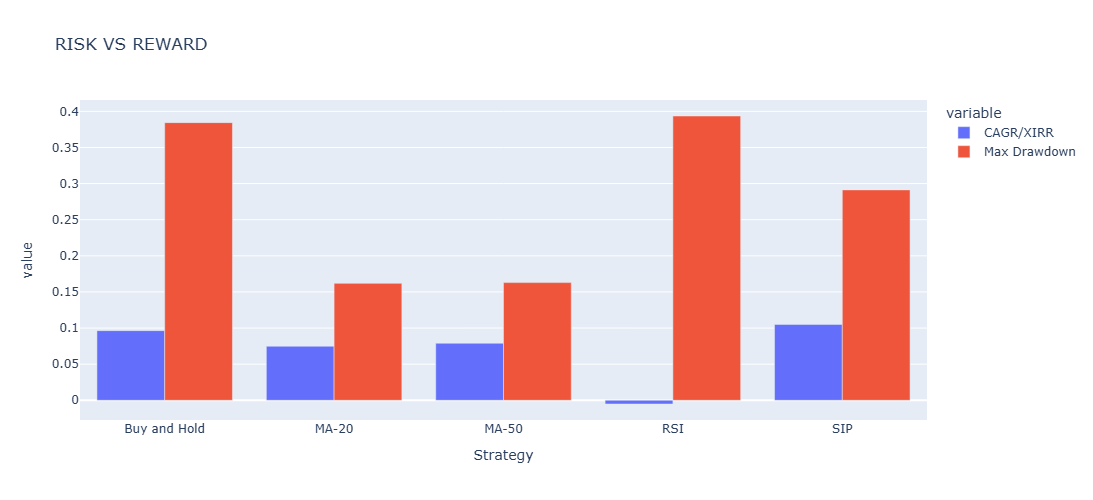

In [187]:
px.bar(comparison_df,
       x='Strategy',
       y=['CAGR/XIRR','Max Drawdown'],
       barmode='group',
      height=500,
      title="RISK VS REWARD" )